# Predicting heart disease using the Machine Learning

This Notebook looks into using the  various Python-based Machine Learning and Data science libreries in an attempt to build a mchine leaning model capable of redicting whether the patient has the heart disease or not based on their medicl attributes

We're going to take the following approach :
1. Problem Defination
2. Data Gathering
3. Evaluation
4. Modelling
5. Experimenting

## 1. Problem Defination
In a statement,
> Given clinical parameters about a patient can we predict whether the patient have the heart disease or not.

## 2. Data
The original came from the cleavland data from the [UCI Machine Repository](https://archive.ics.uci.edu/dataset/45/heart+disease).

**Note** These version is also available on the [Kaggle Heart Disease Dataset](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

## 3. Evaluation
> if we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we will pursue the project as it is critical project.

## 4. Features

* age (Age of the patient in years)
* sex (Male/Female)
* cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
* trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* chol (serum cholesterol in mg/dl)
* fbs (if fasting blood sugar > 120 mg/dl)
* restecg (resting electrocardiographic results) -- Values: [normal, stt abnormality, lv hypertrophy]
* thalach: maximum heart rate achieved
* exang: exercise-induced angina (True/ False)
* oldpeak: ST depression induced by exercise relative to rest
* slope: the slope of the peak exercise ST segment
* ca: number of major vessels (0-3) colored by fluoroscopy
* thal: [normal; fixed defect; reversible defect]
* target (1 for `having heart disease` 0 for `not having heart disease`)

In [3]:
(165/303) * 100

54.45544554455446

## data report 
**Note** The report are aligned to the [Model Data Analysis](./model_data_analysis.ipynb) that we came across.

### Analysis

1. The patient having more heart disease are more. Total heart disease patient are : 165 (which is `54.45%` of the data)
2. from the male heart disease patient there 

In [37]:
# loading the improtant utitlity
from utility import model_utility


# importing the library 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt

# scikit learn Model's
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# model evaluation 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve

In [2]:
# let's load the data-set 
df = pd.read_csv('../data/heart-disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Spliting the data 


In [4]:
X, y = df.drop('target', axis=1), df['target']

In [5]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [6]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [7]:
# splitting into train-test set 
# training set - 80% and the rest 20% is for the testing set 

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                   test_size=0.2) # 0.2 represent the 20% set will be passed to the test set of the data 

In [9]:
type(X_train)

pandas.DataFrame

In [8]:
len(X_train), len(X_test)

(242, 61)

## Modeling 
> Now, we got the data splitted, so now let's `train the model in the training set of the data` and `evaluate the model in the testing set of the data`

## Which estimator we choose to train the model
![Sklearn model Map](../images/modelling/ml_map.svg)

based on the [Sklearn Choosing the Right estimator docs](https://scikit-learn.org/stable/machine_learning_map.html) we are gonna try 3 different `ML estimators`

1. [Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)
2. [RanddomForestClassifier an ensembel model](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)
3. [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)



In [26]:
# put the model in a dictionary 
models = {'Logistic Regression' : LogisticRegression(),
         'KNN' : KNeighborsClassifier(),
         'Random Forest' : RandomForestClassifier()}

# let's try the model and evaluate their score 
different_model_score = model_utility.fit_and_score(models=models,
                           X_train=X_train,
                           y_train=y_train,
                           X_test=X_test,
                           y_test=y_test)

C:\Users\furqa\miniconda3\envs\heart_disease\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
different_model_score

{'Logistic Regression': 0.8688524590163934,
 'KNN': 0.7049180327868853,
 'Random Forest': 0.8688524590163934}

## Model Comparision


In [30]:
model_compares = pd.DataFrame(different_model_score, index=["accuracy"])

In [31]:
model_compares

,Logistic Regression,KNN,Random Forest
accuracy,0.868852,0.704918,0.868852


In [32]:
model_compares.T

,accuracy
Logistic Regression,0.868852
KNN,0.704918
Random Forest,0.868852


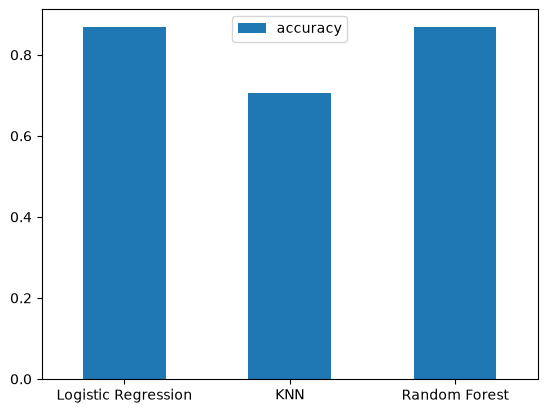

In [43]:
# prepare the plot
ax = model_compares.T.plot(kind='bar');
plt.xticks(rotation=0)
plt.savefig("../images/modelling/001_different_modell_score.png");